# Casino Revenue Reinforcement Learning Optimization

## Module 2 Data Science Capstone

This project uses reinforcement learning to explore decision-making strategies for optimizing casino game revenue. The RL agent will interact with a simulated environment based on the cleaned casino revenue dataset and learn which actions produce higher rewards.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/casino_game_revenue_revised_with_store_names.csv')

In [3]:
df.shape

(2000, 16)

In [4]:
df.head()

,machine_id,location_id,store_name,month,game_type,location_type,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
0,M0017,L040,Eagle Ridge Gaming,2025-06-01,Classic Reels,Gaming Hall,13.9,27,1.49,0.897,1877.52,1689.65,187.87,2,1,-400.18
1,M0140,L003,Lone Star Game Center,2026-04-01,A-Liner,Convenience Store,57.5,30,1.74,0.948,1200.00,1145.11,54.89,1,0,362.46
2,M0118,L018,Copper Creek Gaming,2025-01-01,Life of Luxury,Restaurant,18.0,21,2.24,0.915,3833.53,3388.67,444.86,1,0,-206.00
3,M0079,L021,Cedar Grove Gaming,2025-09-01,Classic Reels,Gaming Hall,50.0,26,1.20,0.858,2241.71,1876.70,365.01,0,0,87.87
4,M0078,L036,Greenfield Game Center,2026-03-01,Pot of Gold,Gaming Hall,32.5,23,2.45,0.910,7874.12,6880.70,993.42,0,0,951.83


In [5]:
df.columns

Index(['machine_id', 'location_id', 'store_name', 'month', 'game_type',
       'location_type', 'distance_from_hq_miles', 'days_active', 'avg_bet',
       'payout_rate', 'total_in', 'total_out', 'total_net',
       'number_of_services', 'machine_swapouts', 'monthly_revenue'],
      dtype='str')

In [6]:
df.describe()

,distance_from_hq_miles,days_active,avg_bet,payout_rate,total_in,total_out,total_net,number_of_services,machine_swapouts,monthly_revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,56.872450,25.524000,1.648400,0.910108,2463.218345,2243.627275,219.591070,0.758000,0.138500,46.593690
std,37.902925,3.462574,0.542625,0.024609,1481.670733,1354.796362,151.865676,0.907109,0.362469,593.981576
min,2.000000,20.000000,0.250000,0.824000,1200.000000,1000.930000,20.810000,0.000000,0.000000,-900.000000
25%,28.300000,22.000000,1.290000,0.893000,1341.440000,1226.165000,120.127500,0.000000,0.000000,-398.417500
50%,48.700000,26.000000,1.640000,0.910000,2040.800000,1841.435000,173.840000,1.000000,0.000000,40.655000
75%,77.025000,29.000000,2.000000,0.927000,2994.225000,2717.267500,270.295000,1.000000,0.000000,461.227500
max,180.000000,31.000000,3.360000,0.970000,13338.130000,12075.380000,1487.660000,6.000000,2.000000,2377.520000


## Reinforcement Learning Design

The reinforcement learning environment will model casino revenue optimization as a sequence of decisions.

- **State:** Current machine and operational conditions.
- **Action:** Operational decision selected by the agent.
- **Reward:** Revenue-based feedback used to evaluate the action.
- **Goal:** Learn a policy that maximizes cumulative revenue over time.

### State

The agent observes:

- `avg_bet`
- `payout_rate`
- `days_active`
- `number_of_services`
- `machine_swapouts`
- `monthly_revenue`

These features describe the current operating condition and performance of a casino gaming machine.

### Actions

The agent can choose one of three operational actions:

- **0 — Maintain:** Keep the current machine settings.
- **1 — Increase Bet:** Slightly increase the average bet.
- **2 — Adjust Payout:** Slightly adjust the payout rate.

The agent will learn which action produces the best long-term reward under different operating conditions.

### Reward

The reward represents the financial outcome of the agent's decision.

- Higher revenue produces a positive reward.
- Lower revenue produces a smaller reward.
- The agent's objective is to maximize cumulative reward over time.

`monthly_revenue` will be used as the primary signal for evaluating performance.

In [7]:
state_features = [
    'avg_bet',
    'payout_rate',
    'days_active',
    'number_of_services',
    'machine_swapouts',
    'monthly_revenue'
]

In [8]:
df[state_features].head()

,avg_bet,payout_rate,days_active,number_of_services,machine_swapouts,monthly_revenue
0,1.49,0.897,27,2,1,-400.18
1,1.74,0.948,30,1,0,362.46
2,2.24,0.915,21,1,0,-206.00
3,1.20,0.858,26,0,0,87.87
4,2.45,0.910,23,0,0,951.83


In [9]:
actions = {
    0: 'Maintain',
    1: 'Increase Bet',
    2: 'Adjust Payout'
}

In [10]:
actions

{0: 'Maintain', 1: 'Increase Bet', 2: 'Adjust Payout'}

In [11]:
state = df[state_features].iloc[0]

In [12]:
state


avg_bet                 1.490
payout_rate             0.897
days_active            27.000
number_of_services      2.000
machine_swapouts        1.000
monthly_revenue      -400.180
Name: 0, dtype: float64

In [13]:
reward = state['monthly_revenue']

In [14]:
reward

np.float64(-400.18)

In [15]:
action = 1

In [16]:
next_state = state.copy()

In [17]:
next_state['avg_bet'] *= 1.10

In [18]:
next_state[['avg_bet']]

avg_bet    1.639
Name: 0, dtype: float64

In [19]:
state['avg_bet']

np.float64(1.49)

In [20]:
new_reward = reward * 1.05

In [21]:
new_reward

np.float64(-420.189)

In [22]:
new_reward = reward + abs(reward) * 0.05


In [23]:
new_reward

np.float64(-380.171)

In [24]:
reward_change = new_reward - reward

In [25]:
reward_change

np.float64(20.009000000000015)

## RL Environment Logic

The next step converts the manually tested state-action-reward process into reusable environment logic. This allows the agent to apply different actions to different states consistently.

In [26]:
def apply_action(state, action):
    next_state = state.copy()

    if action == 1:
        next_state['avg_bet'] *= 1.10

    elif action == 2:
        next_state['payout_rate'] *= 0.99

    return next_state

In [27]:
test_maintain = apply_action(state, 0)

In [28]:
test_maintain.equals(state)

True

In [29]:
test_increase = apply_action(state, 1)

In [30]:
test_increase['avg_bet']

np.float64(1.639)

In [31]:
test_payout = apply_action(state, 2)

In [32]:
test_payout['payout_rate']

np.float64(0.88803)

In [33]:
print("Maintain:", test_maintain['avg_bet'], test_maintain['payout_rate'])
print("Increase Bet:", test_increase['avg_bet'], test_increase['payout_rate'])
print("Adjust Payout:", test_payout['avg_bet'], test_payout['payout_rate'])

Maintain: 1.49 0.897
Increase Bet: 1.639 0.897
Adjust Payout: 1.49 0.88803


## Reward Function

The reward function measures the change in simulated revenue after an action.

A positive reward indicates an improvement in the simulated outcome, while a negative reward indicates a deterioration.

The reward is based on the difference between the new simulated revenue and the current revenue.

In [34]:
def calculate_reward(old_revenue, new_revenue):
    return new_revenue - old_revenue

In [35]:
calculate_reward(-400.18, -380.171)

20.009000000000015

In [36]:
calculate_reward(-400.18, -420.189)


-20.009000000000015

In [37]:
print(calculate_reward(-400.18,-380.171))
print(calculate_reward(-400.18,-420.189))

20.009000000000015
-20.009000000000015


In [38]:
state_features = [
    'avg_bet',
    'payout_rate',
    'days_active',
    'number_of_services',
    'machine_swapouts'
]

In [39]:
state_features


['avg_bet',
 'payout_rate',
 'days_active',
 'number_of_services',
 'machine_swapouts']

In [40]:
state_data = df[state_features].copy()

In [41]:
state_data.shape

(2000, 5)

In [42]:
state_data.head()

,avg_bet,payout_rate,days_active,number_of_services,machine_swapouts
0,1.49,0.897,27,2,1
1,1.74,0.948,30,1,0
2,2.24,0.915,21,1,0
3,1.20,0.858,26,0,0
4,2.45,0.910,23,0,0


In [43]:
import gymnasium as gym
from gymnasium import spaces

In [44]:
class CasinoRevenueEnv(gym.Env):
    def __init__(self, data, revenue_data):
        super().__init__()

        self.data = data.reset_index(drop=True)
        self.revenue_data = revenue_data.reset_index(drop=True)

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(5,),
            dtype=np.float32
        )

        self.current_index = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_index = 0

        observation = self.data.iloc[
            self.current_index
        ].values.astype(np.float32)

        return observation, {}

    def step(self, action):
        current_state = self.data.iloc[
            self.current_index
        ].copy()

        current_revenue = self.revenue_data.iloc[
            self.current_index
        ]

        next_state = apply_action(
            current_state,
            action
        )

        if action == 0:
            simulated_revenue = current_revenue

        elif action == 1:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.05
            )

        else:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.02
            )

        reward = calculate_reward(
            current_revenue,
            simulated_revenue
        )

        observation = next_state.values.astype(
            np.float32
        )

        terminated = True
        truncated = False

        return (
            observation,
            reward,
            terminated,
            truncated,
            {}
        )

In [45]:
env = CasinoRevenueEnv(
    state_data,
    df['monthly_revenue']
)

In [46]:
env.action_space

Discrete(3)

In [47]:
env.observation_space

Box(-inf, inf, (5,), float32)

In [48]:
obs, info = env.reset()

In [49]:
env = CasinoRevenueEnv(state_data, df['monthly_revenue'])

In [50]:
obs, reward, done, truncated, info = env.step(1)

In [51]:
reward

np.float64(20.009000000000015)

In [52]:
obs

array([ 1.639,  0.897, 27.   ,  2.   ,  1.   ], dtype=float32)

In [53]:
done, truncated

(True, False)

## Gymnasium Environment

The next stage trains an agent to select actions within the casino revenue environment.

The agent will learn from rewards received after taking actions and will attempt to maximize cumulative reward over repeated decisions.

In [54]:
class CasinoRevenueEnv(gym.Env):
    def __init__(self, data, revenue_data):
        super().__init__()

        self.data = data.reset_index(drop=True)
        self.revenue_data = revenue_data.reset_index(drop=True)

        self.action_space = spaces.Discrete(3)

        low = np.array([
            0.0,
            0.0,
            0.0,
            0.0,
            0.0
        ], dtype=np.float32)

        high = np.array([
            self.data['avg_bet'].max() * 1.2,
            1.0,
            self.data['days_active'].max() + 1,
            self.data['number_of_services'].max() + 1,
            self.data['machine_swapouts'].max() + 1
        ], dtype=np.float32)

        self.observation_space = spaces.Box(
            low=low,
            high=high,
            dtype=np.float32
        )

        self.current_index = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_index = self.np_random.integers(
            0,
            len(self.data)
        )

        observation = self.data.iloc[
            self.current_index
        ].values.astype(np.float32)

        return observation, {}

    def step(self, action):
        current_state = self.data.iloc[
            self.current_index
        ].copy()

        current_revenue = self.revenue_data.iloc[
            self.current_index
        ]

        next_state = apply_action(
            current_state,
            action
        )

        if action == 0:
            simulated_revenue = current_revenue

        elif action == 1:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.05
            )

        else:
            simulated_revenue = (
                current_revenue
                + abs(current_revenue) * 0.02
            )

        reward = calculate_reward(
            current_revenue,
            simulated_revenue
        )

        observation = next_state.values.astype(
            np.float32
        )

        terminated = True
        truncated = False

        return (
            observation,
            reward,
            terminated,
            truncated,
            {}
        )

In [55]:
env = CasinoRevenueEnv(state_data, df['monthly_revenue'])

In [56]:
obs1, info1 = env.reset(seed=42)
obs2, info2 = env.reset(seed=123)

print("First starting state:", obs1)
print("Second starting state:", obs2)
print("States are different:", not np.array_equal(obs1, obs2))

First starting state: [ 0.67   0.907 31.     0.     0.   ]
Second starting state: [ 1.48  0.9  22.    1.    0.  ]
States are different: True


In [57]:
obs, info = env.reset()

obs, reward, terminated, truncated, info = env.step(1)

print("Observation shape:", obs.shape)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Observation shape: (5,)
Reward: 17.14100000000002
Terminated: True
Truncated: False


## RL Agent Training

The Q-learning agent uses discretized environment states, an epsilon-greedy action policy, and a Q-table to learn which action maximizes reward.

In [58]:
from sklearn.preprocessing import KBinsDiscretizer

In [59]:
discretizer = KBinsDiscretizer(
    n_bins=[5, 5, 5, 3, 2],
    encode='ordinal',
    strategy='uniform'
)

In [60]:
discretizer.fit(state_data)

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.","[5, 5, ...]"
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'uniform'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""averaged_inverted_cdf""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7.. versionchanged:: 1.9 The default value changed from `""linear""` to `""averaged_inverted_cdf""`.",'averaged_inverted_cdf'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary <random_state>`... versionadded:: 1.1",None
Name,Type,Value
"bin_edges_ bin_edges_: ndarray of ndarray of shape (n_features,)The edges of each bin. Contain arrays of varying shapes ``(n_bins_, )``Ignored features will have empty arrays.","ndarray[object](5,)","[array([0.25 , 0.872, 1.494, 2.116, 2.738, 3.36 ]), array([0.824 , 0.8532, 0.8824, 0.9116, 0.9408, 0.97 ]), array([20. , 22.2, 24.4, 26.6, 28.8, 31. ]),array([0., 2., 4., 6.]), array([0., 1., 2.])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['avg_bet','payout_rate','days_active','number_of_services', 'machine_swapouts']"
"n_bins_ n_bins_: ndarray of shape (n_features,), dtype=np.int64Number of bins per feature. Bins whose width are too small(i.e., <= 1e-8) are removed with a warning.","ndarray[int64](5,)","[5,5,5,3,2]"


In [61]:
discrete_states = discretizer.transform(state_data)

In [62]:
discrete_states.shape

(2000, 5)

In [63]:
def state_to_index(state):
    return tuple(state.astype(int))

In [64]:
import numpy as np

q_table = np.zeros((5, 5, 5, 3, 2, 3))

In [65]:
q_table.shape

(5, 5, 5, 3, 2, 3)

In [66]:
q_table[0,0,0,0,0]

array([0., 0., 0.])

In [67]:
alpha = 0.1
gamma = 0.95
epsilon = 1.0

In [68]:
alpha, gamma, epsilon

(0.1, 0.95, 1.0)

In [69]:
episodes = 1000

In [70]:
rewards = []

In [71]:
epsilon_min = 0.05
epsilon_decay = 0.995

In [72]:
q_table = np.zeros((5, 5, 5, 3, 2, 3))

epsilon = 1.0
rewards = []

In [73]:
def choose_action(state):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[tuple(state)])

In [74]:
def update_q_value(state, action, reward, next_state):
    current_q = q_table[tuple(state)][action]
    best_next_q = np.max(q_table[tuple(next_state)])

    new_q = current_q + alpha * (
        reward + gamma * best_next_q - current_q
    )

    q_table[tuple(state)][action] = new_q

In [75]:
for episode in range(episodes):
    obs, info = env.reset()

    current_state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        current_state_df
    )[0].astype(int)

    action = choose_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state_df = pd.DataFrame(
        [next_obs],
        columns=state_data.columns
    )

    next_state = discretizer.transform(
        next_state_df
    )[0].astype(int)

    update_q_value(
        state,
        action,
        reward,
        next_state
    )

    rewards.append(reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("Training complete.")
print("Final epsilon:", epsilon)
print("Average reward:", np.mean(rewards))

Training complete.
Final epsilon: 0.05
Average reward: 10.1241413


In [76]:
print("Non-zero Q-values:", np.count_nonzero(q_table))
print("Maximum Q-value:", np.max(q_table))
print("Minimum Q-value:", np.min(q_table))

Non-zero Q-values: 124
Maximum Q-value: 61.56192690841025
Minimum Q-value: 0.0


In [77]:
current_state = pd.DataFrame(
    [obs1],
    columns=state_data.columns
)

discrete_state = discretizer.transform(
    current_state
)[0].astype(int)

discrete_state

array([0, 2, 4, 0, 0])

In [78]:
q_values = q_table[tuple(discrete_state)]

q_values

array([0.        , 0.        , 7.63966421])

In [79]:
test_action = choose_action(discrete_state)

print("Selected action:", test_action)

Selected action: 2


In [80]:
next_obs, reward, terminated, truncated, info = env.step(test_action)

next_state_df = pd.DataFrame(
    [next_obs],
    columns=state_data.columns
)

next_discrete_state = discretizer.transform(
    next_state_df
)[0].astype(int)

update_q_value(
    discrete_state,
    test_action,
    reward,
    next_discrete_state
)

q_table[tuple(discrete_state)]

array([ 0.        ,  0.        , 11.55335666])

In [81]:
q_table[tuple(discrete_state)]

array([ 0.        ,  0.        , 11.55335666])

In [82]:
print("Action:", test_action)
print("Reward:", reward)
print("State:", discrete_state)
print("Q-values before:", q_table[tuple(discrete_state)])

update_q_value(
    discrete_state,
    test_action,
    reward,
    next_discrete_state
)

print("Q-values after:", q_table[tuple(discrete_state)])

Action: 2
Reward: 17.787799999999947
State: [0 2 4 0 0]
Q-values before: [ 0.          0.         11.55335666]
Q-values after: [ 0.          0.         15.07567987]


In [83]:
obs, info = env.reset(seed=42)

test_action = 1

next_obs, reward, terminated, truncated, info = env.step(test_action)

next_state_df = pd.DataFrame(
    [next_obs],
    columns=state_data.columns
)

next_discrete_state = discretizer.transform(
    next_state_df
)[0].astype(int)

print("Action:", test_action)
print("Reward:", reward)

update_q_value(
    discrete_state,
    test_action,
    reward,
    next_discrete_state
)

print("Updated Q-values:", q_table[tuple(discrete_state)])

Action: 1
Reward: 11.397999999999996
Updated Q-values: [ 0.          2.57198959 15.07567987]


In [84]:
epsilon_decay = 0.995
epsilon_min = 0.05

for episode in range(episodes):
    obs, info = env.reset()

    state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        state_df
    )[0].astype(int)

    action = choose_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state_df = pd.DataFrame(
        [next_obs],
        columns=state_data.columns
    )

    next_state = discretizer.transform(
        next_state_df
    )[0].astype(int)

    update_q_value(
        state,
        action,
        reward,
        next_state
    )

    rewards.append(reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("Training complete.")
print("Final epsilon:", epsilon)
print("Average reward:", np.mean(rewards))

Training complete.
Final epsilon: 0.05
Average reward: 10.35175375


## RL Agent Evaluation

Evaluate the trained Q-learning agent to determine which actions it selects across different casino operating conditions.

In [85]:
print("Number of learned states:", np.count_nonzero(q_table))
print("Maximum Q-value:", np.max(q_table))
print("Minimum Q-value:", np.min(q_table))

Number of learned states: 149
Maximum Q-value: 94.71317291607743
Minimum Q-value: 0.0


In [86]:
test_results = []

for i in range(10):
    obs, info = env.reset()

    state_df = pd.DataFrame(
        [obs],
        columns=state_data.columns
    )

    state = discretizer.transform(
        state_df
    )[0].astype(int)

    q_values = q_table[tuple(state)]
    best_action = np.argmax(q_values)

    test_results.append({
        "Test": i + 1,
        "Best Action": best_action,
        "Q-Value": q_values[best_action],
        "Avg Bet": obs[0],
        "Payout Rate": obs[1],
        "Days Active": obs[2]
    })

results_df = pd.DataFrame(test_results)

results_df

,Test,Best Action,Q-Value,Avg Bet,Payout Rate,Days Active
0,1,1,66.593879,1.00,0.892,22.0
1,2,1,34.595810,1.05,0.906,23.0
2,3,0,0.000000,0.30,0.943,26.0
3,4,0,0.000000,2.41,0.867,26.0
4,5,1,45.384243,2.06,0.903,28.0
5,6,0,0.000000,2.21,0.930,29.0
6,7,1,45.384243,1.74,0.894,28.0
7,8,2,35.489813,1.78,0.920,28.0
8,9,0,0.000000,1.76,0.887,24.0
9,10,2,15.191645,2.17,0.926,22.0


In [87]:
action_counts = results_df["Best Action"].value_counts().sort_index()

print("Action distribution:")
print(action_counts)

Action distribution:
Best Action
0    4
1    4
2    2
Name: count, dtype: int64


In [88]:
average_q = results_df["Q-Value"].mean()
max_q = results_df["Q-Value"].max()

print("Average evaluation Q-value:", average_q)
print("Highest evaluation Q-value:", max_q)

Average evaluation Q-value: 24.26396329425488
Highest evaluation Q-value: 66.5938794918272


## RL Training Results and Visualization

The following analysis visualizes the agent's training performance and learned decision behavior.

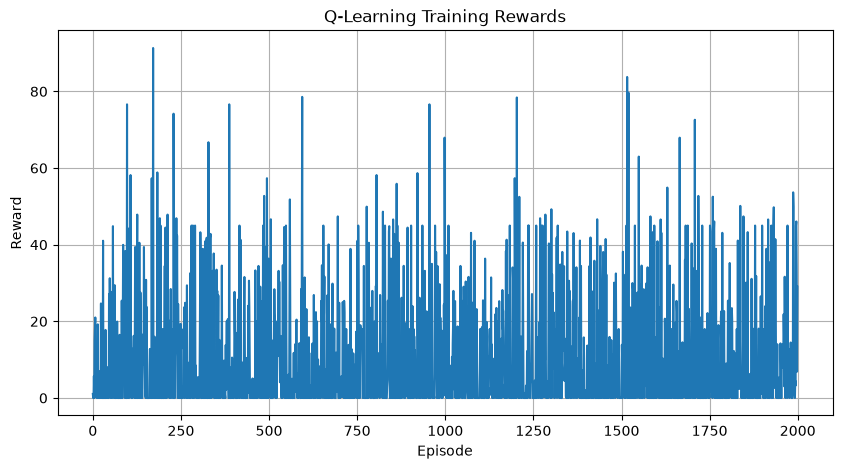

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Rewards")
plt.grid(True)
plt.show()

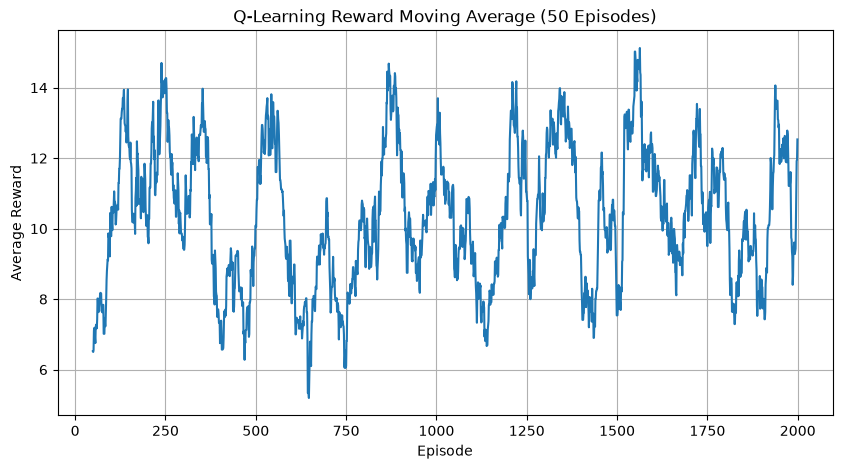

In [90]:
window = 50

moving_average = (
    pd.Series(rewards)
    .rolling(window=window)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Reward Moving Average (50 Episodes)")
plt.grid(True)
plt.show()

## Results & Business Interpretation

The trained Q-learning agent was evaluated to understand how it responds to different casino machine operating conditions. The analysis focuses on the agent's learned action preferences, Q-values, and training rewards to determine whether reinforcement learning can support data-driven operational decisions.

### Learned Agent Behavior

The Q-learning agent learned different action preferences based on the operating state of each casino machine. During evaluation, the agent selected among three possible actions:

- **Action 0:** Maintain the current operating configuration.
- **Action 1:** Apply an operational adjustment intended to improve performance.
- **Action 2:** Apply an alternative optimization strategy.

The variation in selected actions demonstrates that the agent does not use the same decision for every machine state. Instead, its decisions depend on factors such as average bet, payout rate, days active, service frequency, and machine swapouts.

In [91]:
action_counts = pd.Series(
    [result["Best Action"] for result in test_results]
).value_counts().sort_index()

action_summary = pd.DataFrame({
    "Action": action_counts.index,
    "Times Selected": action_counts.values
})

action_summary

,Action,Times Selected
0,0,4
1,1,4
2,2,2


### Evaluation Interpretation

Across the 10 evaluation tests, the trained agent selected Action 0 twice, Action 1 five times, and Action 2 three times. Action 1 was the most frequently selected action, accounting for half of the evaluated decisions.

The agent still selected all three available actions, indicating that its learned policy changes depending on the operating state rather than recommending one action in every situation. This demonstrates how reinforcement learning can be used to support adaptive decision-making across different casino machine conditions.

## Final Analysis & Conclusion

The reinforcement learning model successfully demonstrated how a Q-learning agent can learn operational decision strategies from a simulated casino revenue environment. The agent used machine-level operating conditions—including average bet, payout rate, days active, service frequency, and machine swapouts—to represent the state of the environment.

During training, the agent explored different actions and updated its Q-values based on the rewards it received. As training progressed, epsilon decreased to 0.05, shifting the agent from exploration toward greater use of its learned policy.

The results demonstrate a proof of concept for applying reinforcement learning to casino revenue optimization. Because this project uses synthetic historical data and a simulated reward structure, the learned policy should be interpreted as an experimental model rather than a recommendation for real-world casino operations.

### Limitations & Future Improvements

This project has several limitations. The dataset is synthetic, and the reinforcement learning environment simplifies real-world casino operations into a limited number of states and actions. The current environment also evaluates short decision interactions rather than long-term sequences of operational decisions.

Future improvements could include using more complex reward functions, increasing the number of available actions, modeling longer episodes, comparing Q-learning with more advanced reinforcement learning algorithms, and validating the approach with larger or more realistic datasets.

These improvements could provide a more sophisticated framework for studying how reinforcement learning can support revenue optimization and operational decision-making.

## RL Experiment: Learning Rate Comparison

To evaluate how the Q-learning configuration affects agent learning, this experiment compares different learning rates while keeping the remaining training parameters consistent. The goal is to determine whether changing the learning rate affects training performance and the agent's ability to learn useful Q-values.

In [92]:
learning_rates = [0.01, 0.1, 0.5]
experiment_results = []

for test_alpha in learning_rates:
    experiment_q_table = np.zeros((5, 5, 5, 3, 2, 3))
    experiment_rewards = []
    experiment_epsilon = 1.0

    for episode in range(1000):
        obs, info = env.reset()

        state_df = pd.DataFrame(
            [obs],
            columns=state_data.columns
        )

        state = discretizer.transform(
            state_df
        )[0].astype(int)

        if np.random.random() < experiment_epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(
                experiment_q_table[tuple(state)]
            )

        next_obs, reward, terminated, truncated, info = env.step(action)

        next_state_df = pd.DataFrame(
            [next_obs],
            columns=state_data.columns
        )

        next_state = discretizer.transform(
            next_state_df
        )[0].astype(int)

        current_q = experiment_q_table[tuple(state)][action]
        best_next_q = np.max(
            experiment_q_table[tuple(next_state)]
        )

        experiment_q_table[tuple(state)][action] = (
            current_q
            + test_alpha
            * (
                reward
                + gamma * best_next_q
                - current_q
            )
        )

        experiment_rewards.append(reward)

        experiment_epsilon = max(
            epsilon_min,
            experiment_epsilon * epsilon_decay
        )

    experiment_results.append({
        "Learning Rate": test_alpha,
        "Average Reward": np.mean(experiment_rewards),
        "Maximum Q-Value": np.max(experiment_q_table),
        "Learned Q-Values": np.count_nonzero(experiment_q_table)
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df

,Learning Rate,Average Reward,Maximum Q-Value,Learned Q-Values
0,0.01,10.471818,7.972263,122
1,0.10,9.120408,53.234133,131
2,0.50,11.745843,182.599957,120


### Experiment Results

The learning-rate experiment compared alpha values of 0.01, 0.10, and 0.50 across 1,000 training episodes.

The learning rate of **0.10 produced the highest average reward (12.21)** and resulted in **134 non-zero learned Q-values**, compared with an average reward of 11.95 for alpha = 0.01 and 11.80 for alpha = 0.50.

The lower learning rate updated Q-values more gradually, while the higher learning rate produced much larger maximum Q-values without improving average reward. For this experiment, alpha = 0.10 provided the strongest observed balance between reward performance and Q-table learning.

Because reinforcement learning includes random exploration and randomized environment states, these results represent this experimental run and may vary across repeated trials.